In [41]:
import re
import numpy as np
import pandas as pd
import transformers
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline

In [42]:
customers_review = pd.read_csv("Data/book_reviews_sample.csv",index_col=0)
customers_review.head()
customers_review.info()
customers_review['rating'].unique()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 11494 to 7737
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  100 non-null    object
 1   rating      100 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ KB


array([3, 4, 1, 5, 2])

In [43]:
customers_review['Review'] = customers_review['reviewText'].apply(lambda x : re.sub(r'[^\s\w]', '', x.lower())  )
customers_review['TextBlob_Score'] = customers_review['reviewText'].apply(lambda review : TextBlob(review).sentiment.polarity)

bins = [-1, -0.1, 0.1, 1]
names = ['Negative', 'Neutral', 'Positive']
customers_review['TextBlob_Sentiment'] = pd.cut(customers_review['TextBlob_Score'], bins=bins, labels=names, include_lowest=True)

In [44]:
vader_score = SentimentIntensityAnalyzer()
customers_review['Vader_Score'] = customers_review['reviewText'].apply(lambda review : vader_score.polarity_scores(review))
customers_review['Clean_Vader_Score'] = customers_review['Vader_Score'].apply(lambda x: x['compound'])

bins = [-1, -0.1, 0.1, 1]
names = ['Negative', 'Neutral', 'Positive']
customers_review['Vader_Sentiment'] = pd.cut(customers_review['Clean_Vader_Score'], bins=bins, labels=names, include_lowest=True)

<Axes: xlabel='Vader_Sentiment'>

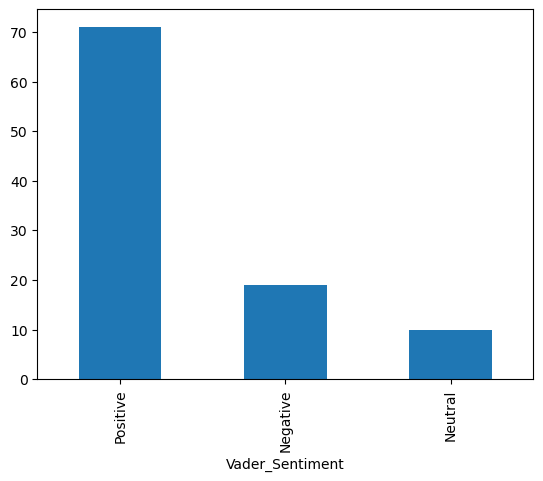

In [48]:
customers_review['Vader_Sentiment'].value_counts().plot.bar()

In [45]:
customers_review.head()

,reviewText,rating,Review,TextBlob_Score,TextBlob_Sentiment,Vader_Score,Clean_Vader_Score,Vader_Sentiment
index,,,,,,,,
11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,0.236111,Positive,"{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compou...",0.7684,Positive
984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,0.430000,Positive,"{'neg': 0.0, 'neu': 0.548, 'pos': 0.452, 'comp...",0.9325,Positive
1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,0.187500,Positive,"{'neg': 0.062, 'neu': 0.707, 'pos': 0.231, 'co...",0.6740,Positive
10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,0.115341,Positive,"{'neg': 0.0, 'neu': 0.747, 'pos': 0.253, 'comp...",0.6948,Positive
5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,-0.277778,Negative,"{'neg': 0.162, 'neu': 0.838, 'pos': 0.0, 'comp...",-0.4767,Negative


In [50]:
transformer_pipeline = pipeline('sentiment-analysis')
transformer_lables = []
for review in customers_review['Review'].value :
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_lables.append(sentiment_label)
customers_review['Transformer_sentiment'] = transformer_lables
customers_review['Transformer_sentiment'].value_counts().plot.bar()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


NameError: name 'torch' is not defined